# Profit-Optimized Credit Risk Model

This notebook builds a credit risk model to predict borrower default probability and then uses expected profit to make loan approval decisions.

## 1. Setup and Imports

This section installs required packages and imports the libraries used for data preparation, modeling, visualization, and profit simulation.

In [ ]:
%pip install --quiet --upgrade pip
%pip install --quiet pandas numpy scikit-learn matplotlib numpy_financial
import pandas as pd
import numpy as np
import numpy_financial as npf
import sklearn as sk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Data Loading

We load the loan dataset and remove identifier fields that do not contribute predictive value.

In [235]:
df = pd.read_csv('/Users/vivaanbhargava/Downloads/Loan_default.csv')
df = df.drop(columns=['LoanID'])

## 3. Loss Given Default (LGD) Assumptions

Before modeling, we define a policy-style LGD function to estimate expected loss severity for each borrower. This will later be used in the profit optimization framework.

In [236]:
def estimate_lgd(row): # lgd estimation based on credit score, cosigner, DTI, and 
    # loan purpose, with a base of 70% and a minimum of 30% and maximum of 95%.
    """
    Policy-style LGD estimate for unsecured consumer lending.
    Benchmark-informed for credit score and DTI, heuristic elsewhere.
    """
    lgd = 0.70

    # 1) CREDIT SCORE
    cs = row["CreditScore"]
    if cs <= 579:
        lgd += 0.12
    elif cs <= 669:
        lgd += 0.06
    elif cs <= 739:
        lgd += 0.00
    elif cs <= 799:
        lgd -= 0.06
    else:
        lgd -= 0.10

    # 2) DTI
    dti = row["DTIRatio"]
    if dti >= 0.50:
        lgd += 0.10
    elif dti >= 0.43:
        lgd += 0.07
    elif dti >= 0.36:
        lgd += 0.03
    elif dti <= 0.20:
        lgd -= 0.05
    elif dti <= 0.30:
        lgd -= 0.02

    # 3) LOAN BURDEN RELATIVE TO INCOME
    income = max(row["Income"], 1)
    loan_to_income = row["LoanAmount"] / income

    if loan_to_income >= 2.5:
        lgd += 0.12
    elif loan_to_income >= 1.5:
        lgd += 0.07
    elif loan_to_income >= 1.0:
        lgd += 0.03
    elif loan_to_income <= 0.25:
        lgd -= 0.04
    elif loan_to_income <= 0.50:
        lgd -= 0.02

    # 4) EMPLOYMENT TYPE
    emp = str(row["EmploymentType"]).strip()
    employment_adj = {
        "Unemployed": 0.10,
        "Part-time": 0.04,
        "Self-employed": 0.02,
        "Full-time": -0.03
    }
    lgd += employment_adj.get(emp, 0.00)

    # 5) MONTHS EMPLOYED
    months_emp = row["MonthsEmployed"]
    if months_emp < 6:
        lgd += 0.05
    elif months_emp < 12:
        lgd += 0.03
    elif months_emp >= 120:
        lgd -= 0.05
    elif months_emp >= 60:
        lgd -= 0.03

    # 6) CO-SIGNER
    if str(row["HasCoSigner"]).strip() == "Yes":
        lgd -= 0.08

    # 7) MORTGAGE / DEPENDENTS
    if str(row["HasMortgage"]).strip() == "Yes":
        lgd += 0.02
    if str(row["HasDependents"]).strip() == "Yes":
        lgd += 0.02

    # 8) NUMBER OF CREDIT LINES
    n_lines = row["NumCreditLines"]
    if n_lines <= 1:
        lgd += 0.04
    elif n_lines <= 3:
        lgd += 0.01
    elif n_lines >= 8:
        lgd -= 0.02

    # 9) LOAN PURPOSE
    purpose = str(row["LoanPurpose"]).strip()
    purpose_adj = {
        "Business": 0.06,
        "Other": 0.03,
        "Education": 0.02,
        "Auto": -0.01,
        "Home": -0.03
    }
    lgd += purpose_adj.get(purpose, 0.00)

    # 10) EDUCATION
    education = str(row["Education"]).strip()
    education_adj = {
        "High School": 0.03,
        "Bachelor's": 0.00,
        "Master's": -0.02,
        "PhD": -0.03
    }
    lgd += education_adj.get(education, 0.00)

    # 11) MARITAL STATUS
    marital = str(row["MaritalStatus"]).strip()
    marital_adj = {
        "Single": 0.01,
        "Divorced": 0.02,
        "Married": -0.01
    }
    lgd += marital_adj.get(marital, 0.00)

    return max(0.30, min(0.95, lgd))

## 4. Target Variable and Base Inputs

We separate the target variable (`Default`) from the borrower features to prepare for modeling.

In [237]:
x = df.drop(columns=['Default'])
y = df['Default']

## 5. Initial Data Preview

We inspect the dataset structure and confirm the available borrower-level variables before feature engineering.

In [250]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 6. Feature Engineering

This section creates additional financial ratios and interaction variables designed to better capture repayment burden, leverage, credit quality, and employment stability.

In [249]:
# feature engineering: ratios and interaction features
df_fe = df.copy()

df_fe["IncomeSafe"] = df_fe["Income"].replace(0, 1)

monthly_rate_all = df_fe["InterestRate"] / 100 / 12
monthly_payment_all = npf.pmt(monthly_rate_all, df_fe["LoanTerm"], -df_fe["LoanAmount"], 0, 0)

df_fe["LoanToIncome"] = df_fe["LoanAmount"] / df_fe["IncomeSafe"]
df_fe["PaymentToIncome"] = monthly_payment_all / (df_fe["IncomeSafe"] / 12)
df_fe["LoanPerCreditLine"] = df_fe["LoanAmount"] / (df_fe["NumCreditLines"] + 1)

df_fe["CreditScore_DTI"] = df_fe["CreditScore"] * df_fe["DTIRatio"]
df_fe["DTI_AdjustedScore"] = df_fe["CreditScore"] / (df_fe["DTIRatio"] + 0.01)

df_fe["EmploymentStability"] = df_fe["MonthsEmployed"] / (df_fe["Age"] * 12 + 1)
df_fe["CreditLinesPerYearEmployed"] = df_fe["NumCreditLines"] / (df_fe["MonthsEmployed"] / 12 + 1)

df_fe["CreditScore_NormalizedLoan"] = df_fe["CreditScore"] / (df_fe["LoanAmount"] + 1)

df_fe["YoungBorrower"] = (df_fe["Age"] < 30).astype(int)
df_fe["SeniorBorrower"] = (df_fe["Age"] > 60).astype(int)

df_fe["InterestBurden"] = ((monthly_payment_all * df_fe["LoanTerm"] - df_fe["LoanAmount"]) / df_fe["IncomeSafe"])

# redefine X and y after feature engineering
x = df_fe.drop(columns=["Default"])
y = df_fe["Default"]

# numeric features including engineered ratios
numeric_features = [
    "Age","Income","LoanAmount","CreditScore","MonthsEmployed",
    "NumCreditLines","InterestRate","LoanTerm","DTIRatio",
    "LoanToIncome","PaymentToIncome","LoanPerCreditLine",
    "CreditScore_DTI","DTI_AdjustedScore",
    "EmploymentStability","CreditLinesPerYearEmployed",
    "CreditScore_NormalizedLoan","YoungBorrower","SeniorBorrower","InterestBurden"
]

# categorical features
categorical_features = [
    "Education","EmploymentType","MaritalStatus",
    "HasMortgage","HasDependents","LoanPurpose","HasCoSigner"
]



## 7. Model Training and Profit Framework

We train a logistic regression model to estimate probability of default, then combine predicted default risk with LGD, EAD, and projected interest income to evaluate expected loan profitability.

In [240]:
# run this segment for profit maximization, rather than just predicting whether a loan will default or not

from sklearn.preprocessing import StandardScaler

# train/test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
LGD = X_test.apply(estimate_lgd, axis=1)
X_test["LGD"] = LGD

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first"), categorical_features)
    ]
)

# pipeline with logistic regression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
])

# fit and evaluate
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
EAD = X_test["LoanAmount"]
monthly_payment = npf.pmt(X_test["InterestRate"] / 100 / 12, X_test["LoanTerm"], -EAD, 0, 0)
interest_income = monthly_payment * (X_test["LoanTerm"]) - EAD
expected_profit = (1 - y_proba) * interest_income - y_proba * (LGD * EAD)
approve = (expected_profit > 0).astype(int)
approved_defaults = y_test[approve == 1].mean()
total_profit = expected_profit[approve == 1].sum()

print("Approval rate:", approve.mean())
print("Average expected profit:", expected_profit.mean())
print("Default rate among approved loans:", approved_defaults)
print("Total expected profit from approved loans:", total_profit)

Approval rate: 0.7491090659878598
Average expected profit: 9551.69017421937
Default rate among approved loans: 0.08325273806100844
Total expected profit from approved loans: 710648817.249974


/Users/vivaanbhargava/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivaanbhargava/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivaanbhargava/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 8. Post-Model Outputs for Analysis

We extract the final prediction arrays and approval decisions for downstream visualization and interpretation.

In [241]:
y_true = np.asarray(y_test)
pd_hat = np.asarray(y_proba)
profit = np.asarray(expected_profit)
appr = np.asarray(approve)

## 9. Model Performance and Business Visualizations

The following plots summarize predictive performance, approval behavior, profit distribution, and the relationship between estimated default risk and lending decisions.

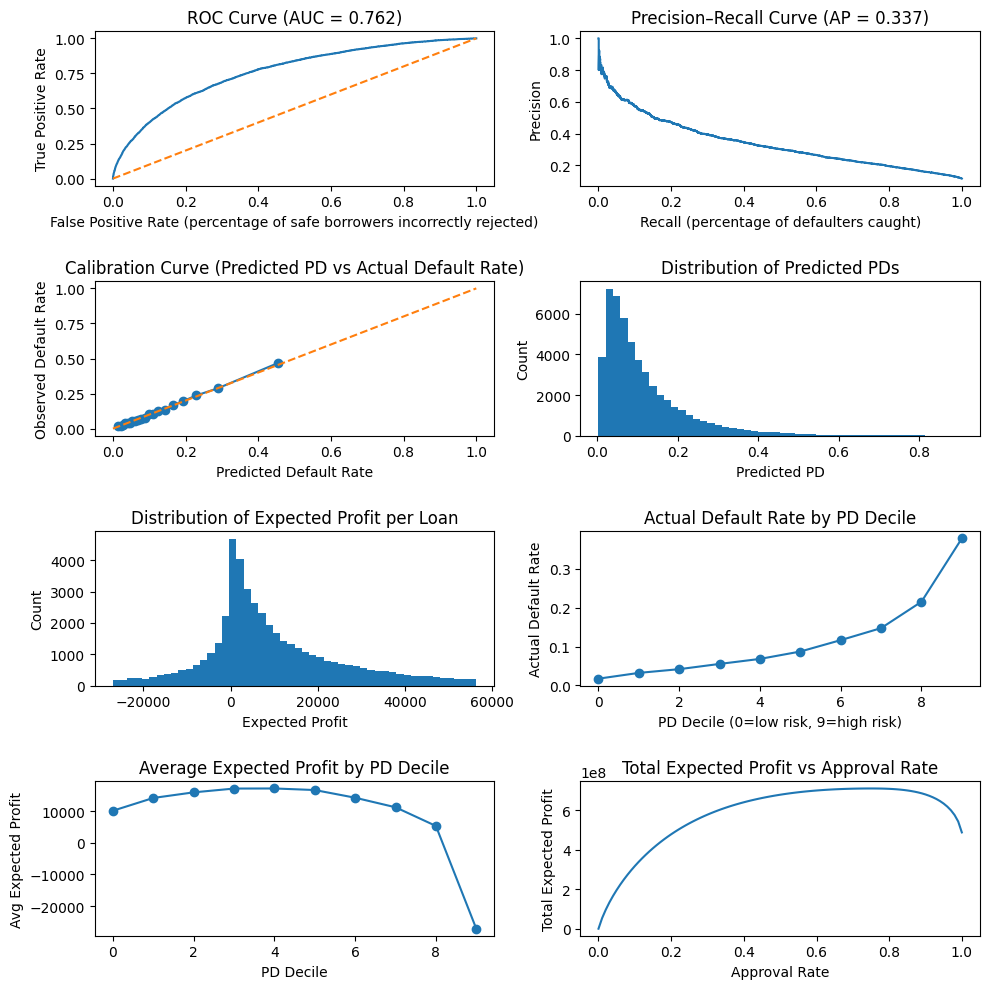

In [242]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes = axes.flatten()

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_true, pd_hat)
auc = roc_auc_score(y_true, pd_hat)

axes[0].plot(fpr, tpr)
axes[0].plot([0,1], [0,1], linestyle="--")
axes[0].set_title(f"ROC Curve (AUC = {auc:.3f})")
axes[0].set_xlabel("False Positive Rate (percentage of safe borrowers incorrectly rejected)")
axes[0].set_ylabel("True Positive Rate")

# ---- Precision Recall ----
prec, rec, _ = precision_recall_curve(y_true, pd_hat)
ap = average_precision_score(y_true, pd_hat)

axes[1].plot(rec, prec)
axes[1].set_title(f"Precision–Recall Curve (AP = {ap:.3f})")
axes[1].set_xlabel("Recall (percentage of defaulters caught)")
axes[1].set_ylabel("Precision")

# ---- Calibration Curve ----
prob_true, prob_pred = calibration_curve(y_true, pd_hat, n_bins=20, strategy="quantile")

axes[2].plot(prob_pred, prob_true, marker="o")
axes[2].plot([0,1], [0,1], linestyle="--")
axes[2].set_title("Calibration Curve (Predicted PD vs Actual Default Rate)")
axes[2].set_xlabel("Predicted Default Rate")
axes[2].set_ylabel("Observed Default Rate")

# ---- PD Distribution ----
axes[3].hist(pd_hat, bins=50)
axes[3].set_title("Distribution of Predicted PDs")
axes[3].set_xlabel("Predicted PD")
axes[3].set_ylabel("Count")

# ---- Profit Distribution ----
axes[4].hist(profit, bins=50, range=(np.percentile(profit, 5), np.percentile(profit, 95)))
axes[4].set_title("Distribution of Expected Profit per Loan")
axes[4].set_xlabel("Expected Profit")
axes[4].set_ylabel("Count")

# ---- Default Rate by PD Decile ----
df_plot = pd.DataFrame({"pd": pd_hat, "y": y_true})
df_plot["decile"] = pd.qcut(df_plot["pd"], 10, labels=False)

decile_default = df_plot.groupby("decile")["y"].mean()

axes[5].plot(decile_default.index, decile_default.values, marker="o")
axes[5].set_title("Actual Default Rate by PD Decile")
axes[5].set_xlabel("PD Decile (0=low risk, 9=high risk)")
axes[5].set_ylabel("Actual Default Rate")

# ---- Profit by PD Decile ----
df_plot["profit"] = profit
decile_profit = df_plot.groupby("decile")["profit"].mean()

axes[6].plot(decile_profit.index, decile_profit.values, marker="o")
axes[6].set_title("Average Expected Profit by PD Decile")
axes[6].set_xlabel("PD Decile")
axes[6].set_ylabel("Avg Expected Profit")

# ---- Profit vs Approval Rate ----
thresholds = np.percentile(profit, np.linspace(0, 100, 101))
approval_rates = []
total_profits = []

for thr in thresholds:
    appr_t = (profit > thr)
    approval_rates.append(appr_t.mean())
    total_profits.append(profit[appr_t].sum())

axes[7].plot(approval_rates, total_profits)
axes[7].set_title("Total Expected Profit vs Approval Rate")
axes[7].set_xlabel("Approval Rate")
axes[7].set_ylabel("Total Expected Profit")

plt.tight_layout()
plt.show()

## 10. Threshold and Profit Sensitivity

This section explores how approval thresholds affect portfolio profit, allowing the model to be interpreted as a decision tool rather than just a classifier.

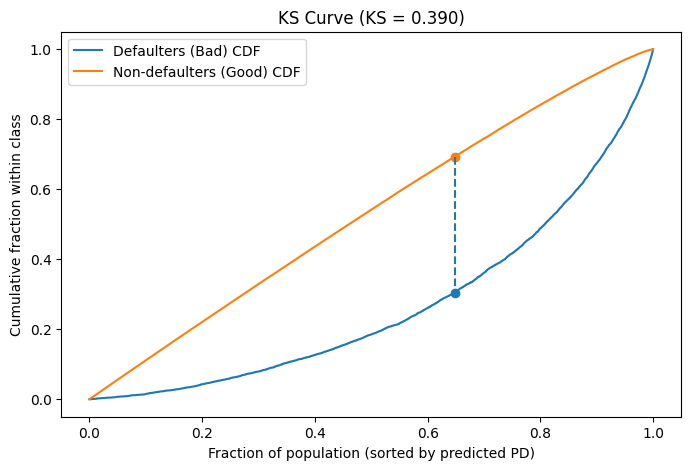

In [243]:
import numpy as np
import matplotlib.pyplot as plt

# y_true: 0/1 actual default labels
# pd_hat: predicted probabilities (y_proba)

y_true = np.asarray(y_true)
pd_hat = np.asarray(pd_hat)

# Sort by predicted PD (low -> high)
order = np.argsort(pd_hat)
y_sorted = y_true[order]

# Separate defaulters vs non-defaulters
is_bad = (y_sorted == 1)
is_good = (y_sorted == 0)

# Cumulative distributions
cum_bad = np.cumsum(is_bad) / is_bad.sum()
cum_good = np.cumsum(is_good) / is_good.sum()

# KS = max vertical gap
ks_vals = np.abs(cum_bad - cum_good)
ks = ks_vals.max()
ks_idx = ks_vals.argmax()

# X-axis: fraction of population (or percentile)
x = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

plt.figure(figsize=(8,5))
plt.plot(x, cum_bad, label="Defaulters (Bad) CDF")
plt.plot(x, cum_good, label="Non-defaulters (Good) CDF")

# Mark KS point
plt.vlines(x[ks_idx], cum_good[ks_idx], cum_bad[ks_idx], linestyles="--")
plt.scatter([x[ks_idx]], [cum_bad[ks_idx]])
plt.scatter([x[ks_idx]], [cum_good[ks_idx]])

plt.title(f"KS Curve (KS = {ks:.3f})")
plt.xlabel("Fraction of population (sorted by predicted PD)")
plt.ylabel("Cumulative fraction within class")
plt.legend()
plt.show()

## 12. Individual Borrower Evaluation Tool

To make the notebook more practical, we define a function that scores a single borrower and returns both predicted risk and business decision outputs.

In [246]:
def evaluate_borrower(values, show_input=True):

    columns = [
        "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
        "NumCreditLines", "InterestRate", "LoanTerm", "DTIRatio",
        "Education", "EmploymentType", "MaritalStatus",
        "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"
    ]
    
    if len(values) != len(columns):
        raise ValueError(f"Expected {len(columns)} values, but got {len(values)}.")
    
    borrower = pd.DataFrame([values], columns=columns)

    # safe income to avoid divide-by-zero
    borrower["IncomeSafe"] = borrower["Income"].replace(0, 1)

    # monthly payment calculation
    monthly_rate = borrower["InterestRate"] / 100 / 12
    monthly_payment_series = npf.pmt(
        monthly_rate,
        borrower["LoanTerm"],
        -borrower["LoanAmount"],
        0,
        0
    )

    # engineered features
    borrower["LoanToIncome"] = borrower["LoanAmount"] / borrower["IncomeSafe"]
    borrower["PaymentToIncome"] = monthly_payment_series / (borrower["IncomeSafe"] / 12)
    borrower["LoanPerCreditLine"] = borrower["LoanAmount"] / (borrower["NumCreditLines"] + 1)

    borrower["InterestBurden"] = (
        (monthly_payment_series * borrower["LoanTerm"] - borrower["LoanAmount"])
        / borrower["IncomeSafe"]
    )

    borrower["CreditScore_DTI"] = borrower["CreditScore"] * borrower["DTIRatio"]
    borrower["DTI_AdjustedScore"] = borrower["CreditScore"] / (borrower["DTIRatio"] + 0.01)

    borrower["EmploymentStability"] = borrower["MonthsEmployed"] / (borrower["Age"] * 12 + 1)
    borrower["CreditLinesPerYearEmployed"] = borrower["NumCreditLines"] / (borrower["MonthsEmployed"] / 12 + 1)

    borrower["CreditScore_NormalizedLoan"] = borrower["CreditScore"] / (borrower["LoanAmount"] + 1)

    borrower["YoungBorrower"] = (borrower["Age"] < 30).astype(int)
    borrower["SeniorBorrower"] = (borrower["Age"] > 60).astype(int)

    # LGD estimate
    borrower["LGD"] = borrower.apply(estimate_lgd, axis=1)

    # probability of default
    pd_hat = model.predict_proba(borrower)[:, 1][0]

    # exposure at default
    EAD = borrower.loc[0, "LoanAmount"]

    # loan pricing inputs
    annual_rate = borrower.loc[0, "InterestRate"] / 100
    monthly_rate_scalar = annual_rate / 12
    n_months = borrower.loc[0, "LoanTerm"]

    # amortization payment
    monthly_payment = npf.pmt(monthly_rate_scalar, n_months, -EAD, 0, 0)

    # interest income
    total_paid = monthly_payment * n_months
    interest_income = total_paid - EAD

    # LGD
    LGD = borrower.loc[0, "LGD"]

    # expected loss / profit
    expected_loss = pd_hat * LGD * EAD
    expected_profit = (1 - pd_hat) * interest_income - expected_loss

    # approval rule
    approved = expected_profit > 0

    if show_input:
        print("INPUT BORROWER")
        print(borrower[columns].to_string(index=False))
        print()

    print("MODEL OUTPUT")
    print(f"Probability of Default (PD): {pd_hat:.4f} ({pd_hat:.2%})")
    print(f"Exposure at Default (EAD or Loan Amount): ${EAD:,.2f}")
    print(f"Estimated LGD: {LGD:.2f}")
    print(f"Monthly Payment: ${monthly_payment:,.2f}")
    print(f"Interest Burden: {borrower.loc[0, 'InterestBurden']:.4f}")
    print(f"Total Interest Income if Repaid: ${interest_income:,.2f}")
    print(f"Expected Loss: ${expected_loss:,.2f}")
    print(f"Expected Profit: ${expected_profit:,.2f}")
    print(f"Decision: {'APPROVED' if approved else 'REJECTED'}")

    return {
        "PD": pd_hat,
        "EAD": EAD,
        "LGD": LGD,
        "MonthlyPayment": monthly_payment,
        "InterestBurden": borrower.loc[0, "InterestBurden"],
        "InterestIncome": interest_income,
        "ExpectedLoss": expected_loss,
        "ExpectedProfit": expected_profit,
        "Approved": approved
    }

## 13. Example Borrower Test Case

We run the scoring function on a sample borrower profile to demonstrate how the model can be used for an individual underwriting decision.

In [247]:
test_borrower = [
    56,             # Age
    90001,          # Income
    50587,          # LoanAmount
    520,            # CreditScore
    80,             # MonthsEmployed
    4,              # NumCreditLines
    15.23,          # InterestRate
    36,             # LoanTerm
    0.44,           # DTIRatio
    "Bachelor's",   # Education
    "Full-time",    # EmploymentType
    "Divorced",     # MaritalStatus
    "Yes",          # HasMortgage
    "Yes",          # HasDependents
    "Other",        # LoanPurpose
    "Yes"           # HasCoSigner
]

evaluate_borrower(test_borrower)

INPUT BORROWER
 Age  Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  InterestRate  LoanTerm  DTIRatio  Education EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose HasCoSigner
  56   90001       50587          520              80               4         15.23        36      0.44 Bachelor's      Full-time      Divorced         Yes           Yes       Other         Yes

MODEL OUTPUT
Probability of Default (PD): 0.0276 (2.76%)
Exposure at Default (EAD or Loan Amount): $50,587.00
Estimated LGD: 0.84
Monthly Payment: $1,759.32
Interest Burden: 0.1416
Total Interest Income if Repaid: $12,748.45
Expected Loss: $1,174.87
Expected Profit: $11,221.11
Decision: APPROVED


{'PD': np.float64(0.02764841525992496),
 'EAD': np.int64(50587),
 'LGD': np.float64(0.84),
 'MonthlyPayment': np.float64(1759.3180449238064),
 'InterestBurden': np.float64(0.14164786632656337),
 'InterestIncome': np.float64(12748.449617257029),
 'ExpectedLoss': np.float64(1174.866321513212),
 'ExpectedProfit': np.float64(11221.108866805662),
 'Approved': np.True_}

## 13. Example Borrower Test Case

We run the scoring function on a sample borrower profile to demonstrate how the model can be used for an individual underwriting decision.

In [248]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", key=abs, ascending=False)

print(coef_df.head(30))

                              feature      coef
0                            num__Age -0.609282
6                   num__InterestRate  0.471483
9                   num__LoanToIncome  0.470515
25     cat__EmploymentType_Unemployed  0.450551
4                 num__MonthsEmployed -0.312957
23      cat__EmploymentType_Part-time  0.280515
34               cat__HasCoSigner_Yes -0.267349
29             cat__HasDependents_Yes -0.258567
24  cat__EmploymentType_Self-employed  0.251165
26         cat__MaritalStatus_Married -0.212526
32              cat__LoanPurpose_Home -0.185917
22                 cat__Education_PhD -0.184448
28               cat__HasMortgage_Yes -0.153591
21            cat__Education_Master's -0.136741
3                    num__CreditScore -0.117183
5                 num__NumCreditLines  0.092849
20         cat__Education_High School  0.076500
27          cat__MaritalStatus_Single -0.062308
30          cat__LoanPurpose_Business  0.059049
8                       num__DTIRatio  0